# 04 Support Vector Machine (SVM) - Email Spam Classification

This is a complete, standalone pipeline for training an SVM model on dirty email data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

sns.set(style='whitegrid')

### 1. Data Cleaning & Preprocessing
Handling the "dirty" attributes (casing, duplicates, and HTML noise).

In [2]:
df = pd.read_csv('../_data/email_spam.csv')
df.columns = [c.lower().replace('-', '_').replace(' ', '_') for c in df.columns]
df = df.drop_duplicates()

def clean_text(text):
    text = re.sub('<.*?>', '', str(text))
    return text.strip().lower()

df['text_clean'] = df['message_content'].apply(clean_text)
df['is_spam'] = df['target_label'].apply(lambda x: 1 if str(x).lower().strip() in ['1', 'spam', 's_p_a_m'] else 0)

X_train, X_test, y_train, y_test = train_test_split(df['text_clean'], df['is_spam'], test_size=0.2, random_state=42)

### 2. Pipeline Building & Training
We use a TF-IDF vectorizer and a Linear SVC model.

In [3]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=3000)),
    ('clf', SVC(kernel='linear', probability=True, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


### 3. Evaluation & Visualization

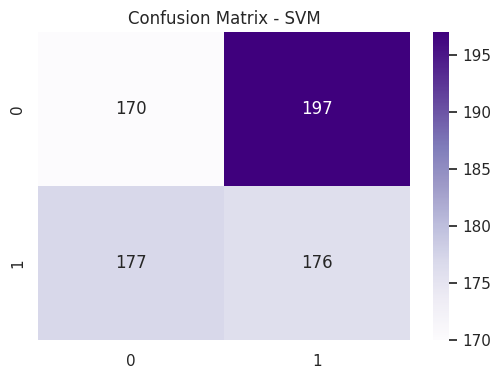

              precision    recall  f1-score   support

           0       0.49      0.46      0.48       367
           1       0.47      0.50      0.48       353

    accuracy                           0.48       720
   macro avg       0.48      0.48      0.48       720
weighted avg       0.48      0.48      0.48       720



In [4]:
y_pred = pipeline.predict(X_test)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - SVM')
plt.show()

print(classification_report(y_test, y_pred))

### 4. Model Saving

In [5]:
joblib.dump(pipeline, '../_model/email_classification_svm.joblib')
print("Model saved.")

Model saved.
